In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('.')

FILES = {
    'feature_component_mapping': OUTPUT_DIR / 'feature_component_mapping.csv',
    'feature_correlation': OUTPUT_DIR / 'feature_correlation.csv',
    'popularity_raw_stats': OUTPUT_DIR / 'popularity_raw_stats.csv',
    'value_raw_stats': OUTPUT_DIR / 'value_raw_stats.csv',
    'popularity_ablation_combinations': OUTPUT_DIR / 'popularity_ablation_combinations.csv',
    'value_ablation_combinations': OUTPUT_DIR / 'value_ablation_combinations.csv',
}

feature_correlation = pd.read_csv(FILES['feature_correlation'], index_col=0)
popularity_raw_stats = pd.read_csv(FILES['popularity_raw_stats'])
value_raw_stats = pd.read_csv(FILES['value_raw_stats'])
popularity_ablation = pd.read_csv(FILES['popularity_ablation_combinations'])
value_ablation = pd.read_csv(FILES['value_ablation_combinations'])

missing_files = [str(path) for path in FILES.values() if not path.exists()]
if missing_files:
    print('File berikut belum ditemukan:')
    for file in missing_files:
        print('-', file)
    print('\nJika notebook dijalankan di Google Colab/Jupyter, upload file CSV atau ubah OUTPUT_DIR.')
else:
    print('Semua file CSV ditemukan.')


Semua file CSV ditemukan.


## Heatmap feature_correlation
menggunakan pearson correlation

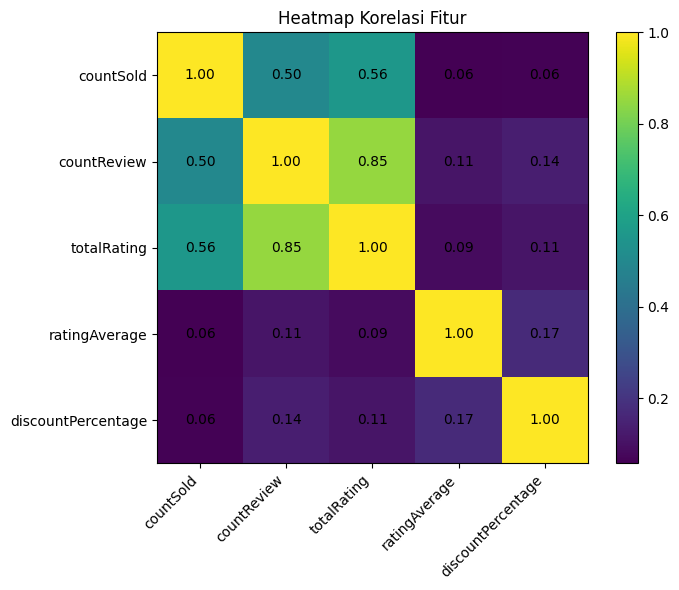

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(feature_correlation.values)

ax.set_xticks(np.arange(len(feature_correlation.columns)))
ax.set_yticks(np.arange(len(feature_correlation.index)))
ax.set_xticklabels(feature_correlation.columns, rotation=45, ha='right')
ax.set_yticklabels(feature_correlation.index)

for i in range(feature_correlation.shape[0]):
    for j in range(feature_correlation.shape[1]):
        ax.text(j, i, f"{feature_correlation.iloc[i, j]:.2f}", ha='center', va='center')

ax.set_title('Heatmap Korelasi Fitur')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


- countReview ↔ totalRating = 0.85 → sangat tinggi. keduanya membawa informasi yang hampir sama — jumlah ulasan dan total rating tumbuh beriringan. Memasukkan keduanya sekaligus dalam komponen β hanya menciptakan redundansi, bukan informasi tambahan.
- countSold ↔ totalRating = 0.56 → sedang. Masih bisa digabungkan karena keduanya mengukur hal berbeda: penjualan mengukur popularitas transaksi, rating mengukur kepuasan akumulatif.
- ratingAverage ↔ semua fitur popularity = 0.06–0.11 → sangat rendah. membuktikan bahwa fitur value dan fitur popularity mengukur dimensi yang benar-benar berbeda, sehingga pemisahan komponen β dan γ dalam formula scoring Anda secara metodologis valid.
- discountPercentage punya kondisi yang sama dengan ratingAvarage.

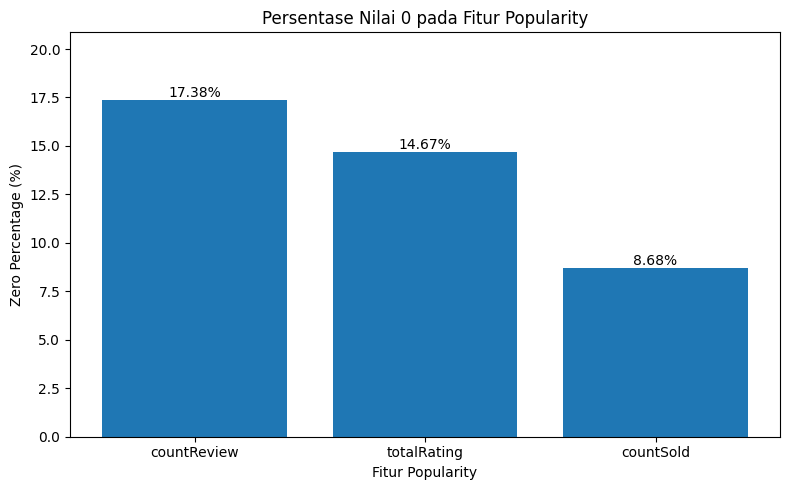

In [6]:
plot_data = popularity_raw_stats.sort_values('zero_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_data['feature'], plot_data['zero_pct'])
ax.set_title('Persentase Nilai 0 pada Fitur Popularity')
ax.set_xlabel('Fitur Popularity')
ax.set_ylabel('Zero Percentage (%)')
ax.set_ylim(0, max(plot_data['zero_pct']) * 1.2 if len(plot_data) else 1)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


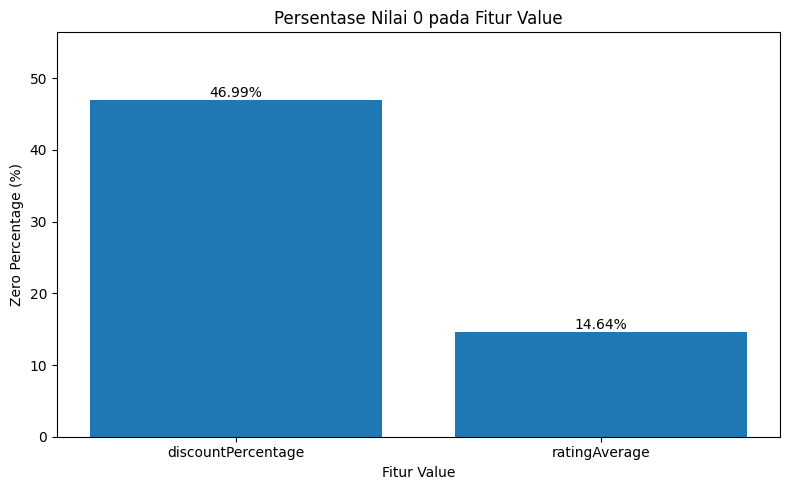

In [7]:
plot_data = value_raw_stats.sort_values('zero_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_data['feature'], plot_data['zero_pct'])
ax.set_title('Persentase Nilai 0 pada Fitur Value')
ax.set_xlabel('Fitur Value')
ax.set_ylabel('Zero Percentage (%)')
ax.set_ylim(0, max(plot_data['zero_pct']) * 1.2 if len(plot_data) else 1)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


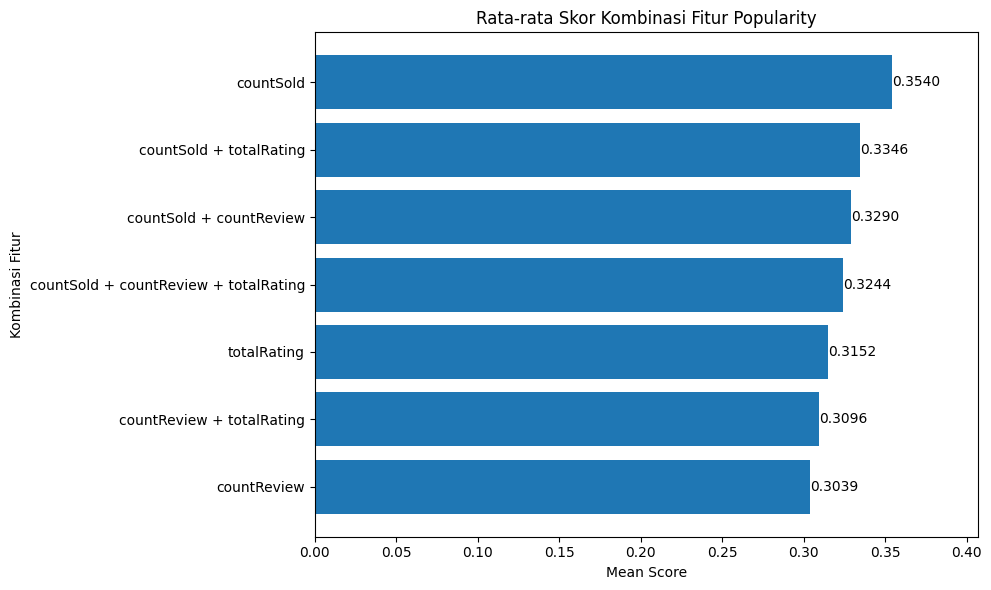

In [8]:
plot_data = popularity_ablation.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data['features'], plot_data['mean'])
ax.set_title('Rata-rata Skor Kombinasi Fitur Popularity')
ax.set_xlabel('Mean Score')
ax.set_ylabel('Kombinasi Fitur')
ax.set_xlim(0, max(plot_data['mean']) * 1.15 if len(plot_data) else 1)

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')

plt.tight_layout()
plt.show()


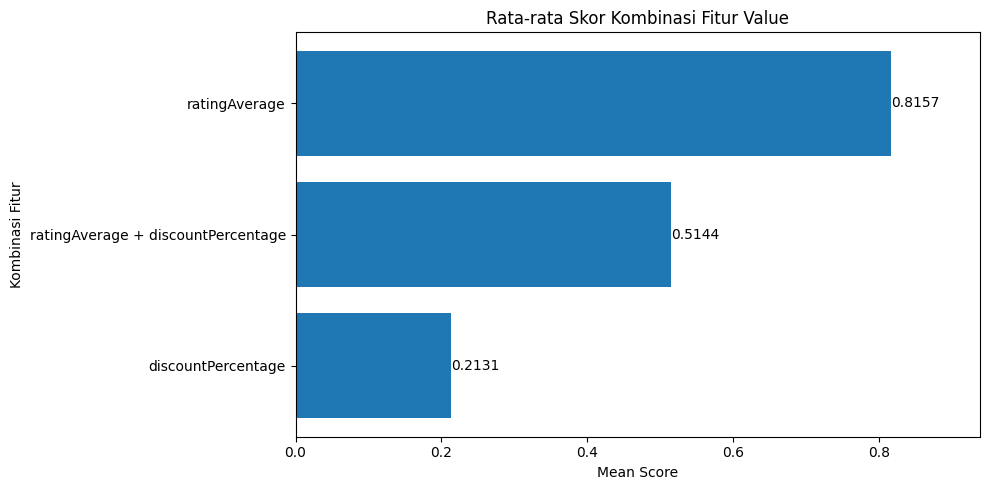

In [9]:
plot_data = value_ablation.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_data['features'], plot_data['mean'])
ax.set_title('Rata-rata Skor Kombinasi Fitur Value')
ax.set_xlabel('Mean Score')
ax.set_ylabel('Kombinasi Fitur')
ax.set_xlim(0, max(plot_data['mean']) * 1.15 if len(plot_data) else 1)

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')

plt.tight_layout()
plt.show()


In [ ]:
# Pasangan korelasi tertinggi di luar diagonal
corr = feature_correlation.copy()
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
top_corr = corr_pairs.sort_values('correlation', ascending=False).iloc[0]

# Fitur dengan zero_pct tertinggi
top_zero_pop = popularity_raw_stats.sort_values('zero_pct', ascending=False).iloc[0]
top_zero_val = value_raw_stats.sort_values('zero_pct', ascending=False).iloc[0]

# Kombinasi dengan mean tertinggi
top_mean_pop = popularity_ablation.sort_values('mean', ascending=False).iloc[0]
top_mean_val = value_ablation.sort_values('mean', ascending=False).iloc[0]

print('KESIMPULAN FEATURE SELECTION')
print('-' * 40)
print(f"1. Korelasi tertinggi terdapat pada {top_corr['feature_1']} dan {top_corr['feature_2']} dengan nilai {top_corr['correlation']:.4f}.")
print(f"2. Pada fitur popularity, zero_pct tertinggi terdapat pada {top_zero_pop['feature']} sebesar {top_zero_pop['zero_pct']:.2f}%.")
print(f"3. Pada fitur value, zero_pct tertinggi terdapat pada {top_zero_val['feature']} sebesar {top_zero_val['zero_pct']:.2f}%.")
print(f"4. Kombinasi popularity dengan mean tertinggi adalah {top_mean_pop['features']} dengan mean {top_mean_pop['mean']:.4f}.")
print(f"5. Kombinasi value dengan mean tertinggi adalah {top_mean_val['features']} dengan mean {top_mean_val['mean']:.4f}.")

KESIMPULAN FEATURE SELECTION
----------------------------------------
1. Korelasi tertinggi terdapat pada countReview dan totalRating dengan nilai 0.8519.
2. Pada fitur popularity, zero_pct tertinggi terdapat pada countReview sebesar 17.38%.
3. Pada fitur value, zero_pct tertinggi terdapat pada discountPercentage sebesar 46.99%.
4. Kombinasi popularity dengan mean tertinggi adalah countSold dengan mean 0.3540.
5. Kombinasi value dengan mean tertinggi adalah ratingAverage dengan mean 0.8157.

Catatan:
Visualisasi ini digunakan untuk memahami distribusi dan hubungan fitur. Pemilihan fitur terbaik tetap perlu diuji pada tahap re-ranking menggunakan metrik evaluasi seperti Precision@K, Recall@K, NDCG@K, dan Fairness@K.
